In [1]:
import pandas as pd
import numpy as np
from sklearn import metrics, ensemble,tree,inspection,model_selection
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split


In [2]:
#url = "https://raw.githubusercontent.com/raghavtwenty/datasets/master/flavors_of_cacao.csv"
# 或者使用 TidyTuesday 整理的版本：
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2022/2022-01-18/chocolate.csv"

df = pd.read_csv(url)
df.head()

,ref,company_manufacturer,company_location,review_date,country_of_bean_origin,specific_bean_origin_or_bar_name,cocoa_percent,ingredients,most_memorable_characteristics,rating
0,2454,5150,U.S.A.,2019,Tanzania,"Kokoa Kamili, batch 1",76%,"3- B,S,C","rich cocoa, fatty, bready",3.25
1,2458,5150,U.S.A.,2019,Dominican Republic,"Zorzal, batch 1",76%,"3- B,S,C","cocoa, vegetal, savory",3.50
2,2454,5150,U.S.A.,2019,Madagascar,"Bejofo Estate, batch 1",76%,"3- B,S,C","cocoa, blackberry, full body",3.75
3,2542,5150,U.S.A.,2021,Fiji,"Matasawalevu, batch 1",68%,"3- B,S,C","chewy, off, rubbery",3.00
4,2546,5150,U.S.A.,2021,Venezuela,"Sur del Lago, batch 1",72%,"3- B,S,C","fatty, earthy, moss, nutty,chalky",3.00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2530 entries, 0 to 2529
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ref                               2530 non-null   int64  
 1   company_manufacturer              2530 non-null   str    
 2   company_location                  2530 non-null   str    
 3   review_date                       2530 non-null   int64  
 4   country_of_bean_origin            2530 non-null   str    
 5   specific_bean_origin_or_bar_name  2530 non-null   str    
 6   cocoa_percent                     2530 non-null   str    
 7   ingredients                       2443 non-null   str    
 8   most_memorable_characteristics    2530 non-null   str    
 9   rating                            2530 non-null   float64
dtypes: float64(1), int64(2), str(7)
memory usage: 197.8 KB


In [4]:
#bucketing the countries in different groups, like dummy variable, and allocate the smallers country 
# into one group based on their obeservations in the dataset
df['company_location'].value_counts(normalize=True)


company_location
U.S.A.                   0.449012
Canada                   0.069960
France                   0.069565
U.K.                     0.052569
Italy                    0.030830
                           ...   
Wales                    0.000395
Martinique               0.000395
St.Vincent-Grenadines    0.000395
Ghana                    0.000395
Suriname                 0.000395
Name: proportion, Length: 67, dtype: float64

In [5]:
freq=df['company_location'].value_counts(normalize=True)
df['company_location']=np.where(df['company_location'].map(freq)<0.33,'others',df.company_location)

In [6]:
df.company_location.value_counts()

company_location
others    1394
U.S.A.    1136
Name: count, dtype: int64

In [7]:
freq1=df['country_of_bean_origin'].value_counts(normalize=True)
df['country_of_bean_origin']=np.where(df['country_of_bean_origin'].map(freq)<0.33,'others',df['country_of_bean_origin'])

In [8]:
df['country_of_bean_origin'].value_counts(normalize=True)

country_of_bean_origin
others              0.759684
Blend               0.061660
Tanzania            0.031225
Belize              0.030040
Papua New Guinea    0.019763
Trinidad            0.016601
U.S.A.              0.013043
Haiti               0.011858
Jamaica             0.009486
Indonesia           0.007905
Uganda              0.007510
Cuba                0.004743
Congo               0.004348
Solomon Islands     0.003953
Panama              0.003557
Ivory Coast         0.002767
Sierra Leone        0.001581
Togo                0.001186
Liberia             0.001186
Nigeria             0.001186
Cameroon            0.001186
Samoa               0.001186
Sri Lanka           0.000791
Tobago              0.000791
Burma               0.000395
Gabon               0.000395
Sumatra             0.000395
China               0.000395
Principe            0.000395
Sulawesi            0.000395
DR Congo            0.000395
Name: proportion, dtype: float64

In [15]:
df['checking']=df['most_memorable_characteristics'].str.split(',')


In [18]:
checking_exploded=df.checking.explode()
checking_exploded.head()

0    rich cocoa
0         fatty
0        bready
1         cocoa
1       vegetal
Name: checking, dtype: str

In [19]:
checking_freq=checking_exploded.value_counts()
print(checking_freq.shape)

(1232,)


In [20]:
type(checking_freq)

pandas.Series

In [21]:
checking_freq=checking_freq.reset_index()
checking_freq

,checking,count
0,cocoa,210
1,sweet,183
2,nutty,177
3,creamy,163
4,roasty,161
...,...,...
1227,hint of smoke,1
1228,intense blueberry,1
1229,Cadbury egg,1
1230,strong nutty,1


In [22]:
type(checking_freq)

pandas.DataFrame

In [28]:
y=df['rating'].apply(lambda x: 1 if x>=3.5 else 0)
X=df.drop(['rating','company_manufacturer'],axis=1)
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=18)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer                                                                                                                              

In [30]:
X_train_nlp=df.loc[X_train.index,'checking']
X_test_nlp=df.loc[X_test.index,'checking']

In [59]:
X_train_nlp = X_train_nlp.apply(
    lambda x: [i.strip().strip('"').strip("'") for i in x]
)

X_test_nlp = X_test_nlp.apply(
    lambda x: [i.strip().strip('"').strip("'") for i in x]
)

In [60]:
print(X_test_nlp)

1283    [sweet, vanilla domintates, nut]
21                 [sliglty dry, papaya]
911         [vanilla, dried fruit, nuts]
78                     [orange, cinamon]
2367             [dry, coarse, hay, off]
                      ...               
266                 [nutty, mild bitter]
1651           [spicy, fragrant, bitter]
1476            [roasty, coffee, rubber]
849          [simple, mild cocoa, fruit]
945       [coarse, perfume, heavy roast]
Name: checking, Length: 835, dtype: object


In [61]:
type(X_train_nlp.iloc[0])

list

In [62]:
vectorizer=TfidfVectorizer(analyzer=lambda x:x)
X_train_nlp_fit=vectorizer.fit_transform(X_train_nlp)
X_test_nlp_fit=vectorizer.transform(X_test_nlp)

In [63]:
vectorizer.get_feature_names_out()   # 每一列对应哪个词
print(X_train_nlp_fit)                      # 每个词对应的 TF-IDF 数值

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4719 stored elements and shape (1695, 739)>
  Coords	Values
  (0, 105)	0.6961532931540809
  (0, 616)	0.5653640232984568
  (0, 189)	0.4424184824241753
  (1, 149)	0.4142315221659212
  (1, 587)	0.5806380127790692
  (1, 497)	0.7009078000422576
  (2, 467)	0.6113492631141524
  (2, 453)	0.7293557087454174
  (2, 437)	0.30707055966056496
  (3, 243)	0.7390981669788086
  (3, 588)	0.48383679101445326
  (3, 23)	0.4686532398580015
  (4, 149)	0.47613495099803005
  (4, 437)	0.4349572025305873
  (4, 632)	0.7642694161124525
  (5, 149)	0.3355582533546904
  (5, 550)	0.5977326476244159
  (5, 636)	0.7280908875747966
  (6, 189)	0.4372298825181845
  (6, 701)	0.714790771857695
  (6, 35)	0.5458059932798607
  (7, 641)	1.0
  (8, 185)	0.46491752277876075
  (8, 542)	0.3600859455965394
  (8, 194)	0.7403965588870131
  :	:
  (1685, 84)	0.7381715176499531
  (1686, 23)	0.6293559561780104
  (1686, 620)	0.5017549322145651
  (1686, 234)	0.5934248633328564
  (168

In [64]:
words = vectorizer.get_feature_names_out()
words

array(['', 'Fruity', 'Roasty', 'XL nibs', 'accesible', 'accessible',
       'acidic', 'alcohol', 'alkalyzed notes', 'almond', 'almost burnt',
       'alocohol', 'aluminum', 'ambiguous', 'anise', 'appealing smoke',
       'artificial', 'ashey', 'assertive', 'astingent', 'astringent',
       'baked bread', 'balanced', 'banana', 'banana nut',
       'banana raspberry', 'base cocoa', 'base cocoa w/ palm notes',
       'basic', 'basic chocolate', 'basic cocoa', 'berries', 'berry',
       'berry notes', 'berry notes with sweet edge', 'bitter',
       'bitter aftertaste', 'black licorice', 'black pepper',
       'black pepper and banana', 'black tea', 'blackberries',
       'blackberry', 'blackberry and cinnamon', 'blackpepper', 'bland',
       'blueberries', 'blueberry', 'bold', 'bold cherry', 'bold citrus',
       'bold olive', 'bourbon', 'brandy', 'bread', 'bread notes',
       'bready', 'brief fruit note', 'bright', 'bright fruit', 'brownie',
       'brownie batter', 'brownie mix', 'brown

In [65]:
tfidf_values = X_train_nlp_fit[0].toarray()[0]
print(tfidf_values)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [66]:
result = pd.DataFrame({
    'word': words,
    'tfidf': tfidf_values
})

result = (
    result[result['tfidf'] > 0]
    .sort_values('tfidf', ascending=False)
)

print(result)

         word     tfidf
105  chemical  0.696153
616     spice  0.565364
189    earthy  0.442418


In [67]:
tfidf_df = pd.DataFrame(
    X_train_nlp_fit.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=X_train_nlp.index)

In [68]:
tfidf_df.head()

,,Fruity,Roasty,XL nibs,accesible,accessible,acidic,alcohol,alkalyzed notes,almond,...,well developed,wet,wheat,whole bean,wild berry,wine,wood,woodsy,woody,yogurt
188,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
264,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
786,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


only use tdidf as the input for training a ligthgbm model 

In [69]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap
import lime
from lime.lime_text import LimeTextExplainer

In [70]:
lgb_model=lgb.LGBMClassifier(max_depth=13,learning_rate=0.05,n_estimators=100,objective='binary',random_state=18)

In [71]:
fitted_lgbm=lgb_model.fit(X_train_nlp_fit,y_train)

[LightGBM] [Info] Number of positive: 625, number of negative: 1070
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 1695, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.368732 -> initscore=-0.537662
[LightGBM] [Info] Start training from score -0.537662
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [72]:
#add some metrics
y_pred=fitted_lgbm.predict(X_test_nlp_fit)
y_prob=fitted_lgbm.predict_proba(X_test_nlp_fit)[:,1]

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.6407185628742516
Precision: 0.604
Recall   : 0.4289772727272727
F1 Score : 0.5016611295681063
ROC AUC  : 0.6987165913796347


In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.80      0.72       483
           1       0.60      0.43      0.50       352

    accuracy                           0.64       835
   macro avg       0.63      0.61      0.61       835
weighted avg       0.63      0.64      0.63       835



In [75]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[384  99]
 [201 151]]


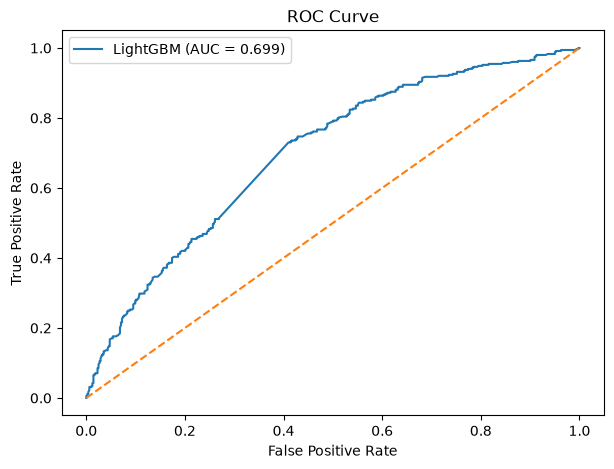

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [77]:
explainer = shap.TreeExplainer(fitted_lgbm)

In [78]:
shap_values = explainer(X_test_nlp_fit)

In [79]:
shap_values.feature_names = list(words)

In [80]:
shap_values

.values =
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38410 stored elements and shape (835, 739)>

.base_values =
array([-0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
       -0.71335481, -0.71335481, -0.71335481, -0.71335481, -0.71335481,
    

In [81]:
print(X_test_nlp.iloc[0])

['sweet', 'vanilla domintates', 'nut']


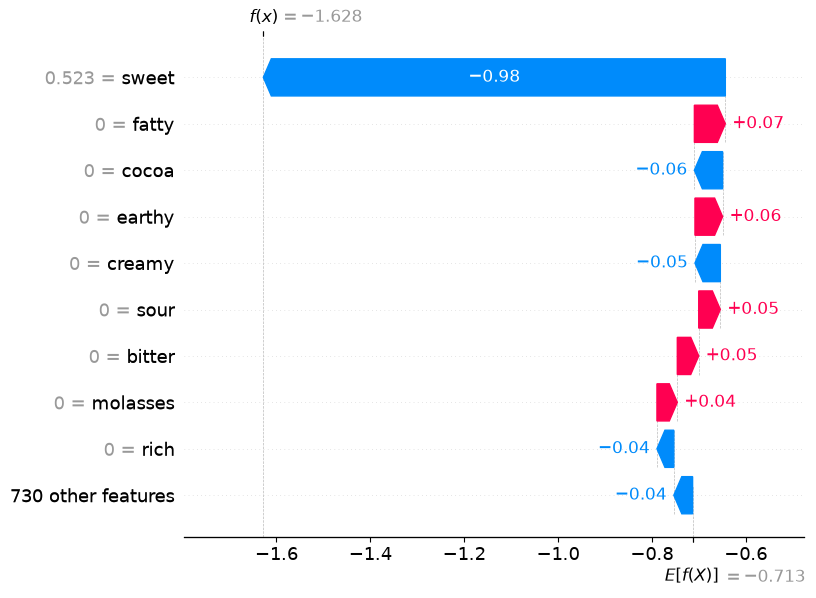

In [82]:
shap.plots.waterfall(
    shap_values[0],
    max_display=10
)

In [83]:
words = vectorizer.get_feature_names_out()

[(i, repr(w)) for i, w in enumerate(words)
 if 'sweet' in w.lower()]

[(34, "'berry notes with sweet edge'"),
 (198, "'extra sweet'"),
 (290, "'intense sweet'"),
 (394, "'mild sweet honey'"),
 (464, "'overly sweet'"),
 (563, "'sl. sweet'"),
 (662, "'sweet'"),
 (663, "'sweet edge'"),
 (664, "'sweet grass'"),
 (665, "'sweet spice'"),
 (666, "'sweet spices'"),
 (687, "'too sweet'"),
 (721, "'very sweet'")]

In [84]:
print("TFIDF features:", X_test_nlp_fit.shape[1])
print("words:", len(words))
print("SHAP features:", shap_values.values.shape[1])

TFIDF features: 739
words: 739
SHAP features: 739


In [57]:
import pandas as pd

s = pd.Series(words)

s[s.duplicated(keep=False)]

Series([], dtype: str)

In [85]:
[(i, repr(w)) for i, w in enumerate(words)
 if 'sweet' in w.lower()]

[(34, "'berry notes with sweet edge'"),
 (198, "'extra sweet'"),
 (290, "'intense sweet'"),
 (394, "'mild sweet honey'"),
 (464, "'overly sweet'"),
 (563, "'sl. sweet'"),
 (662, "'sweet'"),
 (663, "'sweet edge'"),
 (664, "'sweet grass'"),
 (665, "'sweet spice'"),
 (666, "'sweet spices'"),
 (687, "'too sweet'"),
 (721, "'very sweet'")]